## Error analysis (notebook-first)

Minimal helpers to load experiment artifacts, compare predictions on the same rows (`sample_id`), and optionally save a few high-signal CSVs under `error_analysis/`.

- Inputs are **explicit relative paths as strings** (experiment dir or a higher-level run dir).
- Missing/malformed files produce **warnings in the load table**, not crashes.


In [44]:
from __future__ import annotations

from src.error_analysis.io import load_many
from src.error_analysis.reports import aggregate_reports, save_artifacts
from src.error_analysis.compare import (
    build_comparison_df,
    disagreements,
    pairwise_agreement_matrix,
    pairwise_diff,
    confusions,
)

import pandas as pd
import datetime

# Optional plotting deps (safe in notebooks)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1000
pd.options.display.max_colwidth = 1000


In [83]:
TARGETS = [
    r"results/extended_evaluation_ml/20260430_105611",
    r"results/extended_evaluation_llm/20260430_122210/gemma_tweet_eval_irony_test200",
]

'''TARGETS = [
    r"results\extended_evaluation_llm\20260430_092015",
    r"results\baseline_performance\20260428_075211",
    r"results\extended_evaluation_llm\20260430_214911",
    r"results\extended_evaluation_llm\20260430_221556"
]'''

exps, load_table = load_many(TARGETS)
load_table

<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Dmitry\AppData\Local\Temp\ipykernel_31060\2959114128.py:7: SyntaxWarning: invalid escape sequence '\e'
  r"results\extended_evaluation_llm\20260430_092015",


,exp_id,path,ok,has_predictions,has_report,has_config,n_rows_predictions,n_missing,n_warnings,n_errors,warnings,errors
0,emb_umap_head_knn_banking-10_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_banking-10_trainseed100_test200,True,True,True,True,200,0,0,0,,
1,emb_umap_head_knn_banking-10_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_banking-10_traintier5000_test200,True,True,True,True,200,0,0,0,,
2,emb_umap_head_knn_implicit_hate_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_implicit_hate_trainseed100_test200,True,True,True,True,200,0,0,0,,
3,emb_umap_head_knn_implicit_hate_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_implicit_hate_traintier5000_test200,True,True,True,True,200,0,0,0,,
4,emb_umap_head_knn_pubmed_20k_rct_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_pubmed_20k_rct_trainseed100_test200,True,True,True,True,200,0,0,0,,
5,emb_umap_head_knn_pubmed_20k_rct_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_pubmed_20k_rct_traintier5000_test200,True,True,True,True,200,0,0,0,,
6,emb_umap_head_knn_tweet_eval_irony_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_tweet_eval_irony_trainseed100_test200,True,True,True,True,200,0,0,0,,
7,emb_umap_head_knn_tweet_eval_irony_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_tweet_eval_irony_traintier5000_test200,True,True,True,True,200,0,0,0,,
8,emb_umap_head_logreg_banking-10_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_logreg_banking-10_trainseed100_test200,True,True,True,True,200,0,0,0,,
9,emb_umap_head_logreg_banking-10_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_logreg_banking-10_traintier5000_test200,True,True,True,True,200,0,0,0,,


In [84]:
reports_df = aggregate_reports(exps)
reports_df.sort_values(["dataset_name", "f1_macro"], ascending=[True, False]).head(20)

,exp_id,path,ok,dataset_name,tier_size,predictor_name,f1_macro,accuracy,infer_time_s,train_time_s,model_kind,model_id,prompt_id,batch_size,max_concurrency,temperature,max_tokens,retries,in_tokens_total,out_tokens_total,n_warnings,n_errors
17,emb_umap_head_xgb_banking-10_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_xgb_banking-10_traintier5000_test200,True,banking-10,200,emb_umap_head,0.934928,0.935,2.287210,21.000827,emb_umap_head,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
1,emb_umap_head_knn_banking-10_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_banking-10_traintier5000_test200,True,banking-10,200,emb_umap_head,0.934917,0.935,2.244300,18.105496,emb_umap_head,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
9,emb_umap_head_logreg_banking-10_traintier5000_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_logreg_banking-10_traintier5000_test200,True,banking-10,200,emb_umap_head,0.905009,0.905,2.342920,19.377532,emb_umap_head,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
24,setfit_banking-10_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\setfit_banking-10_trainseed100_test200,True,banking-10,200,setfit,0.904580,0.905,0.928262,448.497945,setfit,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
32,svm_banking-10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\svm_banking-10_test200,True,banking-10,200,sklearn_tfidf_svm,0.763366,0.770,0.003850,8.853545,sklearn_svm,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
0,emb_umap_head_knn_banking-10_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_knn_banking-10_trainseed100_test200,True,banking-10,200,emb_umap_head,0.760684,0.770,1.669784,0.980551,emb_umap_head,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
8,emb_umap_head_logreg_banking-10_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_logreg_banking-10_trainseed100_test200,True,banking-10,200,emb_umap_head,0.752457,0.760,1.695516,1.051956,emb_umap_head,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
16,emb_umap_head_xgb_banking-10_trainseed100_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\emb_umap_head_xgb_banking-10_trainseed100_test200,True,banking-10,200,emb_umap_head,0.734428,0.735,6.887679,80.637676,emb_umap_head,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
25,setfit_banking-10_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\setfit_banking-10_trainseed10_test200,True,banking-10,200,setfit,0.655718,0.665,0.637277,43.932492,setfit,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0
36,tfidf_xgb_banking-10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\extended_evaluation_ml\20260430_105611\tfidf_xgb_banking-10_test200,True,banking-10,200,tfidf_xgb,0.214897,0.220,0.115868,16.851350,tfidf_xgb,None,None,NaN,NaN,NaN,None,NaN,NaN,NaN,0,0


In [86]:
reports_df['dataset_name'].unique()

array(['banking-10', 'implicit_hate', 'pubmed_20k_rct',
       'tweet_eval_irony'], dtype=object)

In [154]:
# Compare experiments on the *same dataset rows*.
# If you pass a whole run directory with multiple datasets, filter first.

def _dataset_of(e):
    if e.report and isinstance(e.report.get("dataset_name"), str):
        return e.report["dataset_name"]
    if e.predictions_df is not None and "dataset_name" in e.predictions_df.columns and len(e.predictions_df):
        return str(e.predictions_df["dataset_name"].iloc[0])
    return None

exps_with_preds = [e for e in exps if e.predictions_df is not None]

# Pick a dataset to compare (edit this string in-place)
DATASET = 'banking-10'
exps_ds = [e for e in exps_with_preds if _dataset_of(e) == DATASET]

cmp_df = build_comparison_df(exps_ds, join="inner")
print("dataset=", DATASET, "joined_rows=", len(cmp_df), "n_exps=", len(exps_ds))

diff_df = disagreements(cmp_df)
print("disagreements=", len(diff_df))

a_df = pairwise_agreement_matrix(cmp_df)
a_df

dataset= banking-10 joined_rows= 200 n_exps= 10
disagreements= 177


,emb_umap_head_knn_banking-10_trainseed100_test200,emb_umap_head_knn_banking-10_traintier5000_test200,emb_umap_head_logreg_banking-10_trainseed100_test200,emb_umap_head_logreg_banking-10_traintier5000_test200,emb_umap_head_xgb_banking-10_trainseed100_test200,emb_umap_head_xgb_banking-10_traintier5000_test200,setfit_banking-10_trainseed100_test200,setfit_banking-10_trainseed10_test200,svm_banking-10_test200,tfidf_xgb_banking-10_test200
emb_umap_head_knn_banking-10_trainseed100_test200,1.000,0.760,0.925,0.750,0.800,0.765,0.820,0.635,0.690,0.220
emb_umap_head_knn_banking-10_traintier5000_test200,0.760,1.000,0.765,0.950,0.710,0.965,0.880,0.660,0.770,0.220
emb_umap_head_logreg_banking-10_trainseed100_test200,0.925,0.765,1.000,0.755,0.825,0.765,0.775,0.630,0.685,0.215
emb_umap_head_logreg_banking-10_traintier5000_test200,0.750,0.950,0.755,1.000,0.720,0.920,0.840,0.650,0.735,0.220
emb_umap_head_xgb_banking-10_trainseed100_test200,0.800,0.710,0.825,0.720,1.000,0.720,0.740,0.600,0.615,0.190
emb_umap_head_xgb_banking-10_traintier5000_test200,0.765,0.965,0.765,0.920,0.720,1.000,0.875,0.660,0.770,0.215
setfit_banking-10_trainseed100_test200,0.820,0.880,0.775,0.840,0.740,0.875,1.000,0.645,0.770,0.200
setfit_banking-10_trainseed10_test200,0.635,0.660,0.630,0.650,0.600,0.660,0.645,1.000,0.585,0.195
svm_banking-10_test200,0.690,0.770,0.685,0.735,0.615,0.770,0.770,0.585,1.000,0.235
tfidf_xgb_banking-10_test200,0.220,0.220,0.215,0.220,0.190,0.215,0.200,0.195,0.235,1.000


In [129]:
model_cols = [c for c in diff_df.columns if 'pred_label' in c] + ['true_label']
model_cols

['pred_label__emb_umap_head_knn_implicit_hate_trainseed100_test200',
 'pred_label__emb_umap_head_knn_implicit_hate_traintier5000_test200',
 'pred_label__emb_umap_head_logreg_implicit_hate_trainseed100_test200',
 'pred_label__emb_umap_head_logreg_implicit_hate_traintier5000_test200',
 'pred_label__emb_umap_head_xgb_implicit_hate_trainseed100_test200',
 'pred_label__emb_umap_head_xgb_implicit_hate_traintier5000_test200',
 'pred_label__setfit_implicit_hate_trainseed100_test200',
 'pred_label__setfit_implicit_hate_trainseed10_test200',
 'pred_label__svm_implicit_hate_test200',
 'pred_label__tfidf_xgb_implicit_hate_test200',
 'true_label']

In [ ]:
tier_5000_models = [c for c in model_cols if '5000' in c]
tier_5000_models


['pred_label__emb_umap_head_knn_tweet_eval_irony_traintier5000_test200',
 'pred_label__emb_umap_head_logreg_tweet_eval_irony_traintier5000_test200',
 'pred_label__emb_umap_head_xgb_tweet_eval_irony_traintier5000_test200']

In [ ]:
#diff_df[(diff_df['true_label'] != diff_df['pred_label__gemini_banking10_test200'])][model_cols].index

['pred_label__committee_banking-10_test200',
 'pred_label__gemma_banking-10_test200',
 'pred_label__gemini_banking10_test200',
 'pred_label__svm_banking10_test200',
 'pred_label__gemma_1b_banking-10_test200',
 'pred_label__gemma_26b_banking-10_test200',
 'true_label']

In [139]:
diff_df.columns
ensemble_cols = [
 'pred_label__emb_umap_head_knn_implicit_hate_traintier5000_test200',
 'pred_label__emb_umap_head_logreg_implicit_hate_traintier5000_test200',
 'pred_label__emb_umap_head_xgb_implicit_hate_traintier5000_test200',
 'pred_label__setfit_implicit_hate_trainseed100_test200',
 'pred_label__svm_implicit_hate_test200']

[
    'pred_label__emb_umap_head_xgb_banking-10_traintier5000_test200',
 'pred_label__emb_umap_head_knn_banking-10_traintier5000_test200',
 'pred_label__setfit_banking-10_trainseed100_test200',
 'pred_label__emb_umap_head_xgb_banking-10_traintier5000_test200',
 'pred_label__tfidf_xgb_banking-10_test200',
 'pred_label__svm_banking-10_test200'
 ]

# find majority vote and compare to true_label
diff_df[ensemble_cols].mode(axis=1).iloc[:, 0]
diff_df['majority_vote'] = diff_df[ensemble_cols].mode(axis=1).iloc[:, 0]
diff_df['true_label'] == diff_df['majority_vote']

# find rows where true_label != majority_vote
diff_df[diff_df['true_label'] != diff_df['majority_vote']][ensemble_cols].shape


(70, 5)

In [125]:
(200-13)/200

0.935

In [140]:
# find rows with wild disagreement among ensemble models
# count entropy of ensemble predictions

import numpy as np

def entropy(x):
    # Convert string labels to contiguous integer codes for each row
    # Map (unique per row) label -> code
    labels, encoded = np.unique(x, return_inverse=True)
    counts = np.bincount(encoded)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-12))  # small epsilon avoids log(0)

diff_df = diff_df.copy()  # immutability: don't mutate original DataFrame
diff_df['ensemble_entropy'] = diff_df[ensemble_cols].apply(lambda row: entropy(row.values), axis=1)
interesting_cols = ['true_label', 'majority_vote'] + ensemble_cols + ['ensemble_entropy']
bad_label_condition = (diff_df['true_label'] != diff_df['majority_vote'])
high_entropy_condition = (diff_df['ensemble_entropy'] > 0.9)
diff_df[high_entropy_condition][interesting_cols]

,true_label,majority_vote,pred_label__emb_umap_head_knn_implicit_hate_traintier5000_test200,pred_label__emb_umap_head_logreg_implicit_hate_traintier5000_test200,pred_label__emb_umap_head_xgb_implicit_hate_traintier5000_test200,pred_label__setfit_implicit_hate_trainseed100_test200,pred_label__svm_implicit_hate_test200,ensemble_entropy
1,Non-HS,Non-HS,Non-HS,HS,Non-HS,Non-HS,HS,0.970951
3,Non-HS,Non-HS,Non-HS,Non-HS,Non-HS,HS,HS,0.970951
6,Non-HS,HS,Non-HS,HS,HS,Non-HS,HS,0.970951
7,Non-HS,Non-HS,Non-HS,HS,Non-HS,Non-HS,HS,0.970951
8,HS,Non-HS,Non-HS,Non-HS,HS,Non-HS,HS,0.970951
9,Non-HS,HS,HS,HS,Non-HS,Non-HS,HS,0.970951
11,Non-HS,Non-HS,Non-HS,Non-HS,HS,Non-HS,HS,0.970951
12,HS,Non-HS,Non-HS,Non-HS,HS,Non-HS,HS,0.970951
13,Non-HS,HS,Non-HS,HS,Non-HS,HS,HS,0.970951
17,Non-HS,Non-HS,Non-HS,HS,Non-HS,Non-HS,HS,0.970951


In [145]:
confidence_cols = [c for c in diff_df.columns if 'confidence' in c]
confidence_cols

['confidence__emb_umap_head_knn_implicit_hate_trainseed100_test200',
 'confidence__emb_umap_head_knn_implicit_hate_traintier5000_test200',
 'confidence__emb_umap_head_logreg_implicit_hate_trainseed100_test200',
 'confidence__emb_umap_head_logreg_implicit_hate_traintier5000_test200',
 'confidence__emb_umap_head_xgb_implicit_hate_trainseed100_test200',
 'confidence__emb_umap_head_xgb_implicit_hate_traintier5000_test200',
 'confidence__setfit_implicit_hate_trainseed100_test200',
 'confidence__setfit_implicit_hate_trainseed10_test200',
 'confidence__svm_implicit_hate_test200',
 'confidence__tfidf_xgb_implicit_hate_test200',
 'ensemble_confidence']

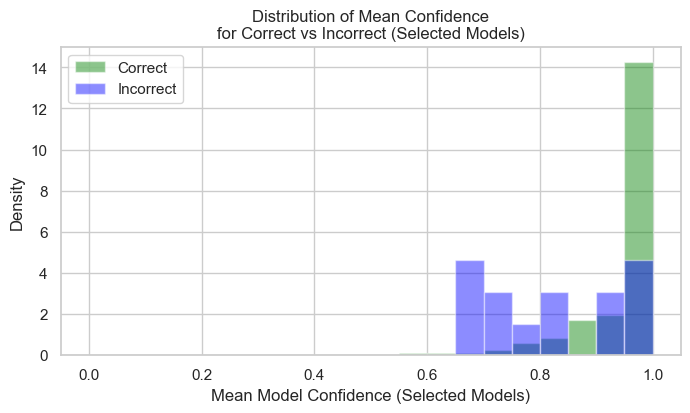

Mean confidence (correct):   0.948
Mean confidence (incorrect): 0.820
T-test p-value: 0.00395


In [157]:
# Analyze model confidence vs correctness for selected models

import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Define the selected confidence columns and corresponding prediction columns
selected_conf_cols = [
    'confidence__emb_umap_head_knn_banking-10_traintier5000_test200',
    'confidence__emb_umap_head_logreg_banking-10_traintier5000_test200',
    'confidence__emb_umap_head_xgb_banking-10_traintier5000_test200',
    'confidence__setfit_banking-10_trainseed100_test200',
]
selected_pred_cols = [
    'pred_label__emb_umap_head_knn_banking-10_traintier5000_test200',
    'pred_label__emb_umap_head_logreg_banking-10_traintier5000_test200',
    'pred_label__emb_umap_head_xgb_banking-10_traintier5000_test200',
    'pred_label__setfit_banking-10_trainseed100_test200',
]

# Compute average confidence score for each row across the selected models
diff_df = diff_df.copy()
diff_df['selected_avg_confidence'] = diff_df[selected_conf_cols].mean(axis=1)

# Compute majority vote for the selected models
def row_majority_vote(row):
    counts = row.value_counts()
    if len(counts) == 0:
        return None
    return counts.idxmax()

diff_df['selected_majority_vote'] = diff_df[selected_pred_cols].apply(row_majority_vote, axis=1)
diff_df['selected_correct'] = diff_df['selected_majority_vote'] == diff_df['true_label']

# Plot histogram of average confidence for correct / incorrect
plt.figure(figsize=(8, 4))
bins = list([round(i, 2) for i in np.linspace(0, 1, 21)])  # (safest sequence of floats for bins)
plt.hist(
    diff_df[diff_df['selected_correct']]['selected_avg_confidence'],
    bins=bins, alpha=0.45, label="Correct", color='green', density=True
)
plt.hist(
    diff_df[~diff_df['selected_correct']]['selected_avg_confidence'],
    bins=bins, alpha=0.45, label="Incorrect", color='blue', density=True, 
)
plt.xlabel("Mean Model Confidence (Selected Models)")
plt.ylabel("Density")
plt.title("Distribution of Mean Confidence\nfor Correct vs Incorrect (Selected Models)")
plt.legend()
plt.show()

# Optionally, show summary statistics:
conf_correct = diff_df[diff_df['selected_correct']]['selected_avg_confidence']
conf_incorrect = diff_df[~diff_df['selected_correct']]['selected_avg_confidence']
print(f"Mean confidence (correct):   {conf_correct.mean():.3f}")
print(f"Mean confidence (incorrect): {conf_incorrect.mean():.3f}")
t_stat, p_val = ttest_ind(conf_correct, conf_incorrect, equal_var=False)
print(f"T-test p-value: {p_val:.3g}")


In [ ]:
# Optional: inspect a pairwise diff
ids = [e.exp_id for e in exps_with_preds]
if len(ids) >= 2:
    a_id, b_id = ids[0], ids[1]
    pair_diff = pairwise_diff(cmp_df, a_id, b_id)
    pair_diff.head(20)

In [ ]:
# Optional: confusion pairs for a chosen experiment id
if exps_with_preds:
    exp0 = exps_with_preds[0].exp_id
    confusions(cmp_df, exp0, top_k=20)

In [94]:
# Save a small set of derived artifacts (opt-in)
specific_keyword = "ml_extended_tweet_eval_irony"
cur_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = r"error_analysis/" + (specific_keyword + "_" if specific_keyword else "") + cur_time

save_artifacts(
    out_dir=out_dir,
    exps=exps,
    reports_df=reports_df,
    disagreements_df=diff_df if "diff_df" in globals() else None,
    agreement_df=a_df if "a_df" in globals() else None,
    # save_comparison_wide=True,  # off by default (can be large)
)
print("saved to", out_dir)

saved to error_analysis/ml_extended_tweet_eval_irony_20260501_112944


In [131]:
# --- Meta reporting (time/quality/tokens) ---

meta = reports_df.copy()

for c in [
    "f1_macro",
    "accuracy",
    "infer_time_s",
    "train_time_s",
    "in_tokens_total",
    "out_tokens_total",
    "tier_size",
]:
    if c in meta.columns:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")

# convenience columns
meta["tokens_total"] = meta[["in_tokens_total", "out_tokens_total"]].sum(axis=1, min_count=1)
meta["sec_per_row"] = meta["infer_time_s"] / meta["tier_size"]

cols = [
    "dataset_name",
    "exp_id",
    "predictor_name",
    "model_kind",
    "model_id",
    "prompt_id",
    "tier_size",
    "f1_macro",
    "accuracy",
    "infer_time_s",
    "sec_per_row",
    "train_time_s",
    "in_tokens_total",
    "out_tokens_total",
    "tokens_total",
    "batch_size",
    "max_concurrency",
    "temperature",
    "retries",
]
cols = [c for c in cols if c in meta.columns]

meta_view = meta[cols].sort_values(["dataset_name", "f1_macro"], ascending=[True, False])
meta_view

,dataset_name,exp_id,predictor_name,model_kind,model_id,prompt_id,tier_size,f1_macro,accuracy,infer_time_s,sec_per_row,train_time_s,in_tokens_total,out_tokens_total,tokens_total,batch_size,max_concurrency,temperature,retries
17,banking-10,emb_umap_head_xgb_banking-10_traintier5000_test200,emb_umap_head,emb_umap_head,None,None,200,0.934928,0.935,2.287210,0.011436,21.000827,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,banking-10,emb_umap_head_knn_banking-10_traintier5000_test200,emb_umap_head,emb_umap_head,None,None,200,0.934917,0.935,2.244300,0.011222,18.105496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,banking-10,emb_umap_head_logreg_banking-10_traintier5000_test200,emb_umap_head,emb_umap_head,None,None,200,0.905009,0.905,2.342920,0.011715,19.377532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,banking-10,setfit_banking-10_trainseed100_test200,setfit,setfit,None,None,200,0.904580,0.905,0.928262,0.004641,448.497945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,banking-10,svm_banking-10_test200,sklearn_tfidf_svm,sklearn_svm,None,None,200,0.763366,0.770,0.003850,0.000019,8.853545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,banking-10,emb_umap_head_knn_banking-10_trainseed100_test200,emb_umap_head,emb_umap_head,None,None,200,0.760684,0.770,1.669784,0.008349,0.980551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,banking-10,emb_umap_head_logreg_banking-10_trainseed100_test200,emb_umap_head,emb_umap_head,None,None,200,0.752457,0.760,1.695516,0.008478,1.051956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,banking-10,emb_umap_head_xgb_banking-10_trainseed100_test200,emb_umap_head,emb_umap_head,None,None,200,0.734428,0.735,6.887679,0.034438,80.637676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,banking-10,setfit_banking-10_trainseed10_test200,setfit,setfit,None,None,200,0.655718,0.665,0.637277,0.003186,43.932492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,banking-10,tfidf_xgb_banking-10_test200,tfidf_xgb,tfidf_xgb,None,None,200,0.214897,0.220,0.115868,0.000579,16.851350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


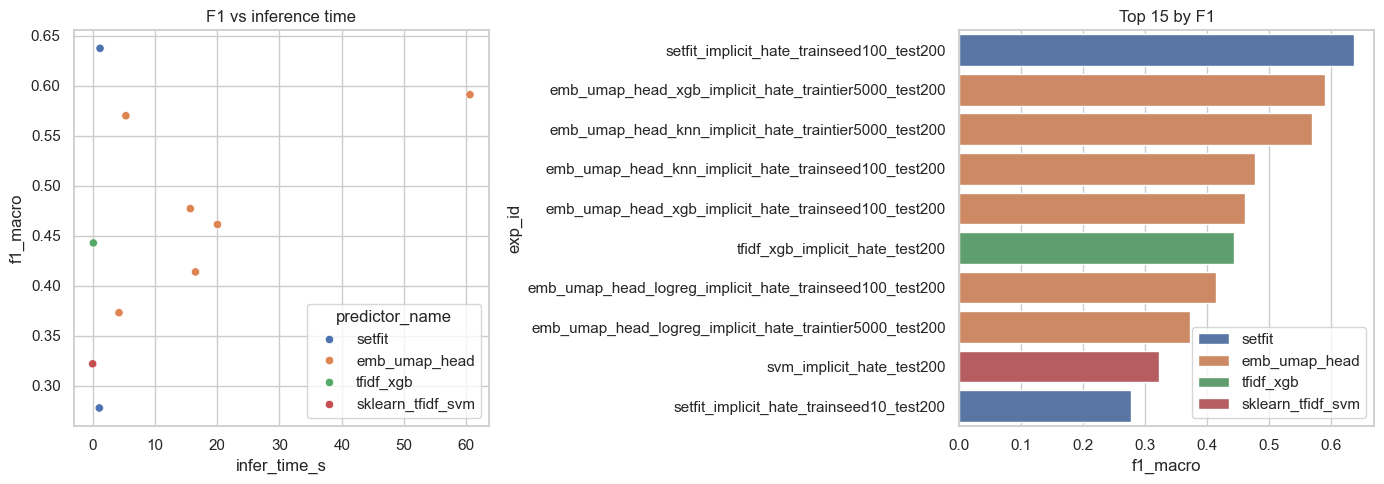

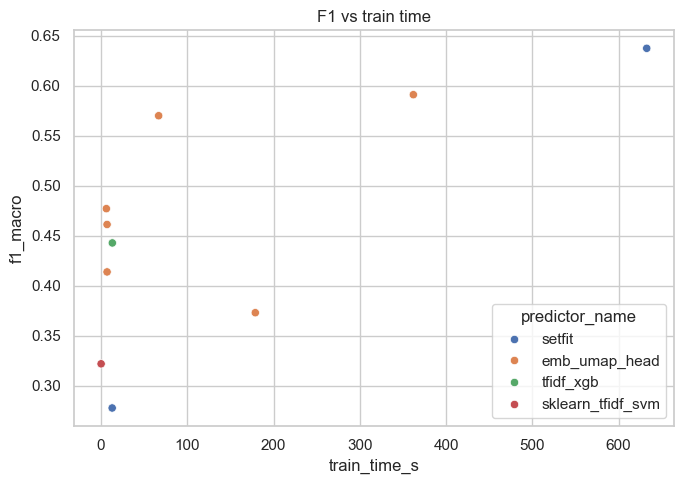

In [132]:
# --- Seaborn overview plots ---

# Filter to the chosen dataset for clean visuals
m = meta_view.copy()
m = m[m["dataset_name"] == DATASET].copy() if "DATASET" in globals() and "dataset_name" in m.columns else m

# Drop missing metrics for plotting
m1 = m.dropna(subset=[c for c in ["f1_macro", "accuracy", "infer_time_s"] if c in m.columns]).copy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if {"infer_time_s", "f1_macro"}.issubset(m1.columns):
    sns.scatterplot(data=m1, x="infer_time_s", y="f1_macro", hue="predictor_name", ax=ax[0])
    ax[0].set_title("F1 vs inference time")

if {"f1_macro", "exp_id"}.issubset(m1.columns):
    top = m1.sort_values("f1_macro", ascending=False).head(15)
    sns.barplot(data=top, y="exp_id", x="f1_macro", hue="predictor_name", dodge=False, ax=ax[1])
    ax[1].set_title("Top 15 by F1")
    ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Optional: train time vs F1 (useful for SetFit)
if {"train_time_s", "f1_macro"}.issubset(m.columns):
    m2 = m.dropna(subset=["train_time_s", "f1_macro"]).copy()
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=m2, x="train_time_s", y="f1_macro", hue="predictor_name")
    plt.title("F1 vs train time")
    plt.tight_layout()
    plt.show()

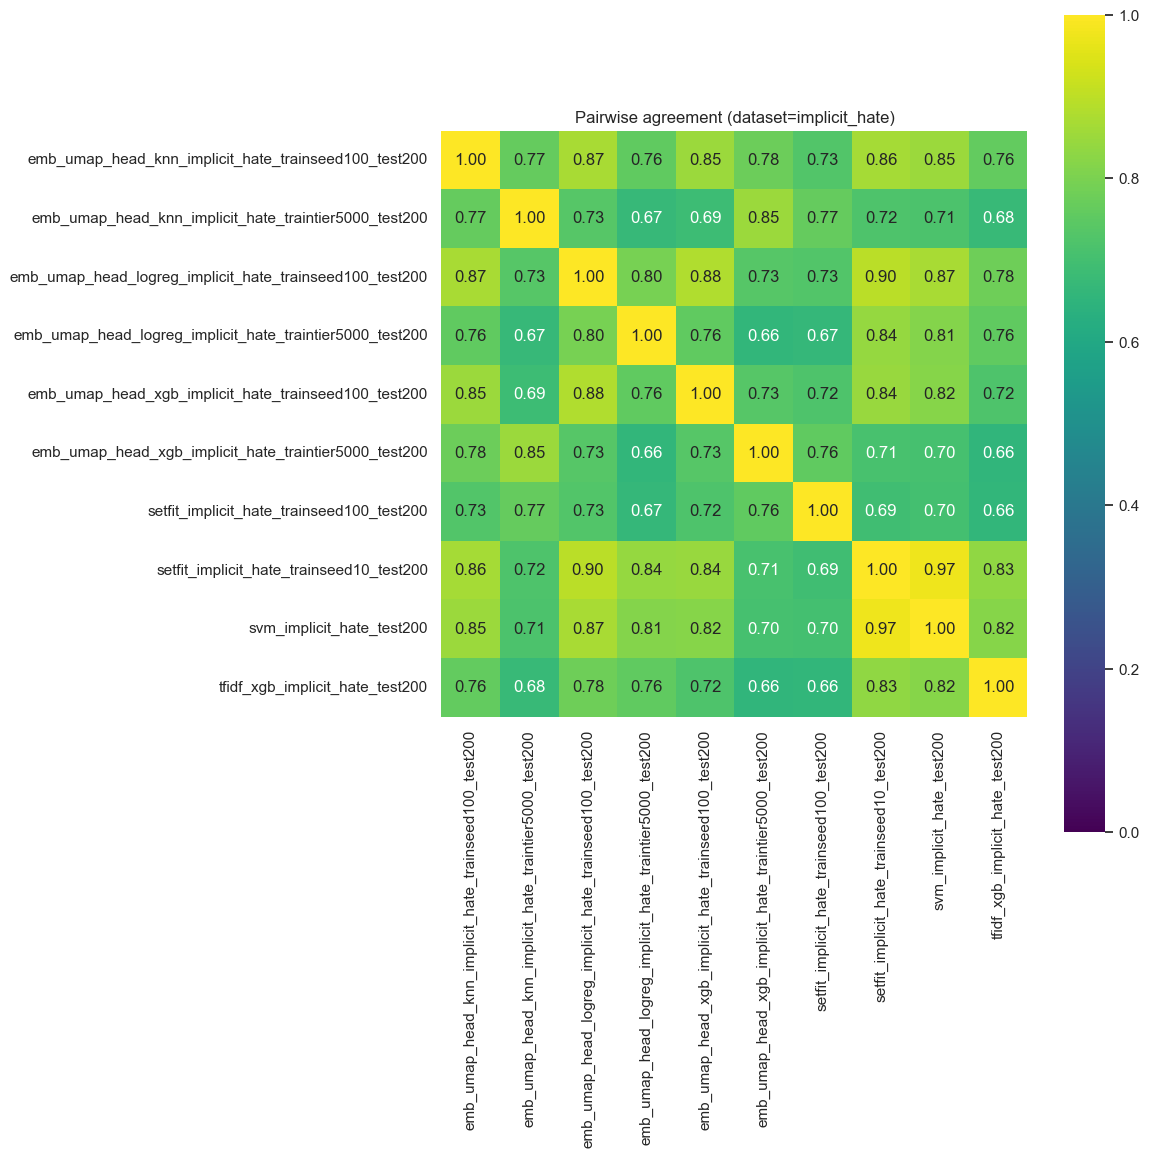

In [133]:
# --- Agreement matrix heatmap ("correlation"-like comparison of predictions) ---

if "a_df" in globals() and hasattr(a_df, "empty") and not a_df.empty:
    plt.figure(figsize=(0.8 * len(a_df.columns) + 4, 0.8 * len(a_df) + 4))
    sns.heatmap(a_df, annot=True, fmt=".2f", cmap="viridis", vmin=0.0, vmax=1.0, square=True)
    plt.title(f"Pairwise agreement (dataset={DATASET})")
    plt.tight_layout()
    plt.show()
else:
    print("No agreement matrix available (a_df is empty). Make sure you built cmp_df for a single dataset.")